<a href="https://colab.research.google.com/github/EMANFATIMA06/DATA-SCIENCE-ANALYTICS/blob/main/Credit%20Risk%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

***Task 2: Credit Risk Prediction***

***Step 1: Import Libraries***

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')  # Suppress unnecessary warnings

***Step 2: Load and Inspect the Dataset***

In [ ]:
# Load the dataset
df = pd.read_csv('/content/loan_dataset_20000.csv')

print(f'Shape: {df.shape}')  # rows x columns
df.head()

Shape: (20000, 22)


,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [ ]:
# Check data types and missing values
print('Dataset Info:')
df.info()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_o

In [ ]:
# Count missing values per column
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64


***EDA: Loan Paid Back Distribution***

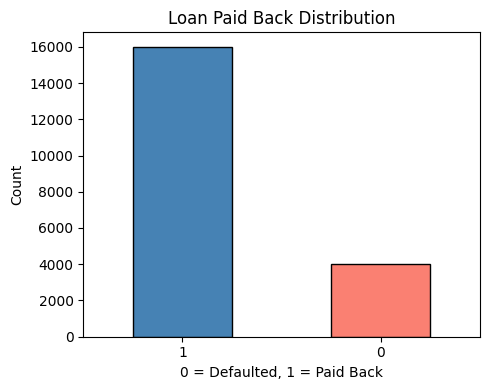

In [ ]:
plt.figure(figsize=(5, 4))
df['loan_paid_back'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Loan Paid Back Distribution')
plt.xlabel('0 = Defaulted, 1 = Paid Back')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

***EDA: Credit Score vs Loan Status***

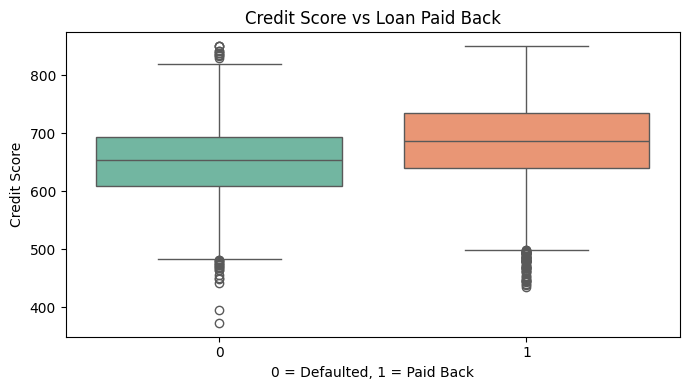

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='loan_paid_back', y='credit_score', palette='Set2')
plt.title('Credit Score vs Loan Paid Back')
plt.xlabel('0 = Defaulted, 1 = Paid Back')
plt.ylabel('Credit Score')
plt.tight_layout()
plt.show()

Observation: Customers who paid back loans tend to have higher credit scores.

 ***EDA: Debt-to-Income Ratio vs Loan Status***

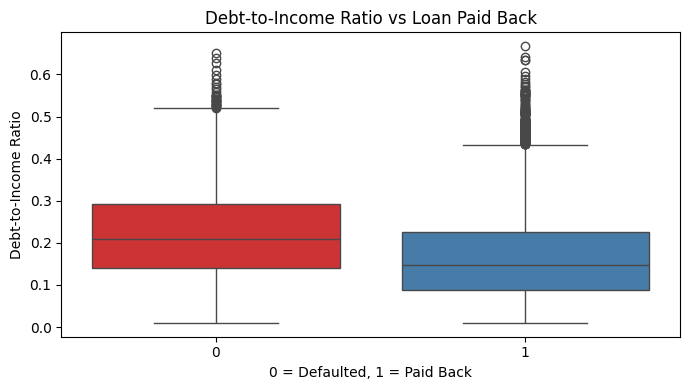

In [ ]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='loan_paid_back', y='debt_to_income_ratio', palette='Set1')
plt.title('Debt-to-Income Ratio vs Loan Paid Back')
plt.xlabel('0 = Defaulted, 1 = Paid Back')
plt.ylabel('Debt-to-Income Ratio')
plt.tight_layout()
plt.show()

Observation: Defaulters tend to have a higher debt-to-income ratio.

***EDA: Loan Purpose***

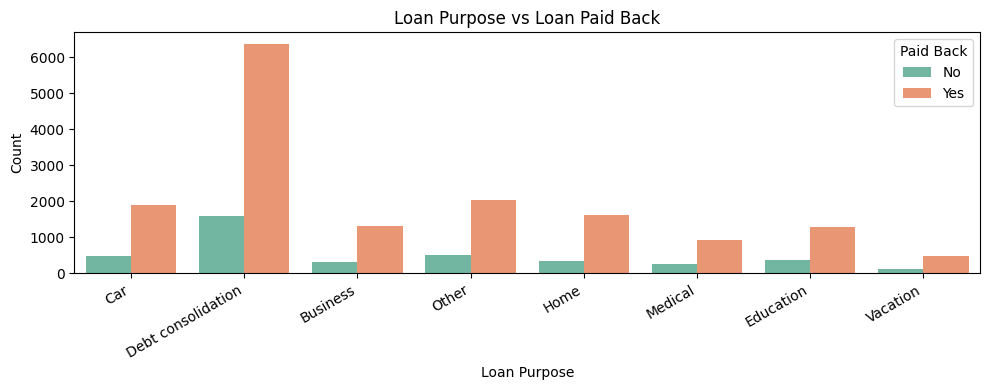

In [ ]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='loan_purpose', hue='loan_paid_back', palette='Set2')
plt.title('Loan Purpose vs Loan Paid Back')
plt.xlabel('Loan Purpose')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Paid Back', labels=['No', 'Yes'])
plt.tight_layout()
plt.show()

***Encode Categorical Columns***

In [ ]:
# These columns are text — we convert them to numbers
le = LabelEncoder()
cat_cols = ['gender', 'marital_status', 'education_level', 'employment_status', 'loan_purpose', 'grade_subgrade']

for col in cat_cols:
    df[col] = le.fit_transform(df[col])
df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,1,1,2,24240.19,2020.02,0,0.074,743,17173.72,...,36,581.88,9,7,40833.47,24302.07,1,0,1,1
1,72,0,1,0,20172.98,1681.08,0,0.219,531,22663.89,...,60,573.17,25,5,27968.01,10803.01,1,0,3,1
2,49,0,2,1,26181.80,2181.82,0,0.234,779,3631.36,...,60,76.32,8,2,15502.25,4505.44,0,0,0,1
3,35,0,2,1,11873.84,989.49,0,0.264,809,14939.23,...,36,468.07,4,7,18157.79,5525.63,4,0,5,1
4,63,2,2,3,25326.44,2110.54,0,0.260,663,16551.71,...,60,395.50,19,1,17467.56,3593.91,2,0,2,1


In [ ]:
X = df.drop('loan_paid_back', axis=1)   # all columns except target
y = df['loan_paid_back']                 # target column

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')

Training samples: 16000
Testing samples:  4000


In [ ]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print('Logistic Regression Accuracy:', accuracy_score(y_test, y_pred_lr)*100)
print('Decision Tree Accuracy:', accuracy_score(y_test, y_pred_dt)*100)

Logistic Regression Accuracy: 87.55
Decision Tree Accuracy: 89.3


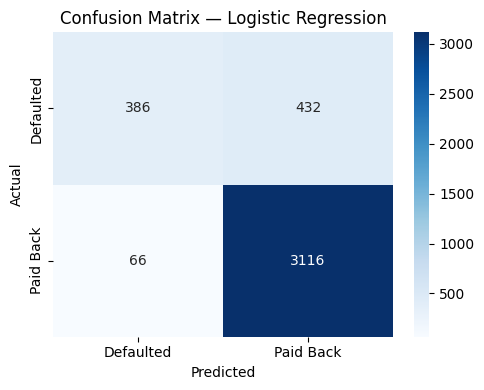

              precision    recall  f1-score   support

   Defaulted       0.85      0.47      0.61       818
   Paid Back       0.88      0.98      0.93      3182

    accuracy                           0.88      4000
   macro avg       0.87      0.73      0.77      4000
weighted avg       0.87      0.88      0.86      4000



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Defaulted', 'Paid Back'],
            yticklabels=['Defaulted', 'Paid Back'])
plt.title('Confusion Matrix — Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_lr, target_names=['Defaulted', 'Paid Back']))

***Conclusion***

1. Dataset: 20,000 loans, no missing values, 22 features.
2. Target: 1 = Paid Back (80%), 0 = Defaulted (20%) — imbalanced dataset.
3. Key Findings:
   - Higher credit score = more likely to pay back.
   - Higher debt-to-income ratio = more likely to default.
   - Credit score and installment amount are the strongest predictors.
4. Both models performed well. Decision Tree gives clear feature importance.
5. Business Use: Banks can use this model to flag high-risk applicants before approving loans.